In [1]:
import sys, os
sys.path.append(os.pardir)

import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.util import smooth_curve
from common.multi_layer_net import MultiLayerNet
from SGD import SGD


In [2]:
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

train_size = x_train.shape[0]
batch_size = 128
max_iterations = 2000

In [3]:
weight_init_types = {'std=0.01': 0.01, 'Xavier': 'sigmoid', 'He': 'relu'}
optimizer = SGD(lr=0.01)

networks = {}
train_loss = {}
for key, weight_type in weight_init_types.items():
    networks[key] = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100],
                                  output_size=10, weight_init_std=weight_type)
    train_loss[key] = []



In [4]:
for i in range(max_iterations):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    for key in weight_init_types.keys():
        grads = networks[key].gradient(x_batch, t_batch)
        optimizer.update(networks[key].params, grads)

        loss = networks[key].loss(x_batch, t_batch)
        train_loss[key].append(loss)

    if i % 100 == 0:
        print("===========" + "iteration:" + str(i) + "===========")
        for key in weight_init_types.keys():
            loss = networks[key].loss(x_batch, t_batch)
            print(key + ":" + str(loss))


===========iteration:0===========
std=0.01:2.302526788630207
Xavier:2.3048106383402795
He:2.324256735458296
===========iteration:100===========
std=0.01:2.302558001179179
Xavier:2.2378397404568524
He:1.484254353267125
===========iteration:200===========
std=0.01:2.301350646075184
Xavier:2.109749715237967
He:0.7115400782004258
===========iteration:300===========
std=0.01:2.3006225711995576
Xavier:1.709936371912371
He:0.503862470480694
===========iteration:400===========
std=0.01:2.3026316626444268
Xavier:1.2675222898168572
He:0.42832461805598604
===========iteration:500===========
std=0.01:2.299339138178925
Xavier:0.894647737551608
He:0.4418769539925567
===========iteration:600===========
std=0.01:2.303288669947582
Xavier:0.5831890326124936
He:0.2710150742773879
===========iteration:700===========
std=0.01:2.300403042258056
Xavier:0.6036605960253989
He:0.389280611015721
===========iteration:800===========
std=0.01:2.2989458966544536
Xavier:0.4199998405101941
He:0.2578140201607785
======

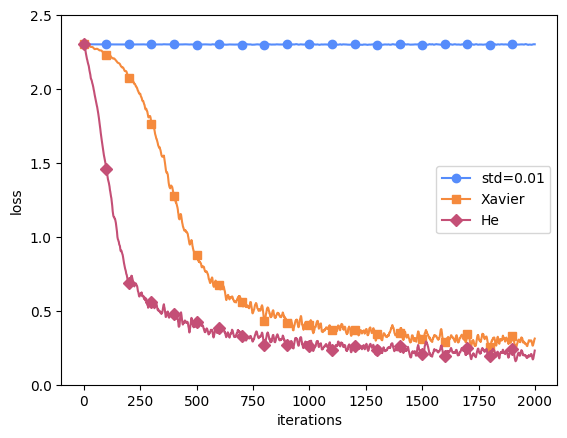

In [5]:
markers = {'std=0.01': 'o', 'Xavier': 's', 'He': 'D'}
x = np.arange(max_iterations)
for key in weight_init_types.keys():
    plt.plot(x, smooth_curve(train_loss[key]), marker=markers[key], markevery=100, label=key)
plt.xlabel("iterations")
plt.ylabel("loss")
plt.ylim(0, 2.5)
plt.legend()
plt.show()